In [62]:
#!pip install datasets
from IPython.display import display

import pandas as pd
from datasets import load_dataset
import json 
import numpy as np
from scipy.stats import pearsonr
import statistics
import pickle

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [63]:
OUTPUT_PATH = "/Users/rahulmehta/Desktop/Job2026/Companies/AmitySolutions/datasets/EDA"

In [64]:
persona = load_dataset("LLM-Digital-Twin/Twin-2K-500", "full_persona")
print("Persona Dataset")
print(persona)
persona_df = persona["data"].to_pandas()


wave_split = load_dataset("LLM-Digital-Twin/Twin-2K-500", "wave_split")

# Save this dataset to disk
#wave_split.save_to_disk("/Users/rahulmehta/Desktop/Job2026/Companies/AmitySolutions/datasets/wave_splits")

wave_split["data"].to_json("/Users/rahulmehta/Desktop/Job2026/Companies/AmitySolutions/datasets/wave_splits/wave_splits.json")
print("Wave Q&A Dateset")
print(wave_split)
wave_df = wave_split["data"].to_pandas()

# Example: Using wave_split for persona creation and evaluation
# train_data = wave_split["data"]["wave1_3_persona_text"]  # or wave1_3_persona_json
# test_questions = wave_split["data"]["wave4_Q_wave4_A"] # you want to remove the "Answers" from all questions
# ground_truth = wave_split["data"]["wave4_Q_wave4_A"]

Persona Dataset
DatasetDict({
    data: Dataset({
        features: ['pid', 'persona_text', 'persona_summary', 'persona_json'],
        num_rows: 2058
    })
})


Creating json from Arrow format: 100%|██████████| 3/3 [00:11<00:00,  3.72s/ba]


Wave Q&A Dateset
DatasetDict({
    data: Dataset({
        features: ['pid', 'wave1_3_persona_text', 'wave1_3_persona_json', 'wave4_Q_wave1_3_A', 'wave4_Q_wave4_A'],
        num_rows: 2058
    })
})


### Dataset Statistics

In [65]:
print(persona_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2058 entries, 0 to 2057
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   pid              2058 non-null   object
 1   persona_text     2058 non-null   object
 2   persona_summary  2058 non-null   object
 3   persona_json     2058 non-null   object
dtypes: object(4)
memory usage: 64.4+ KB
None


In [66]:
##### Unique Persons

print(f"Number of uniques persons {persona_df['pid'].nunique()}")


Number of uniques persons 2058


In [67]:
persona_df['persona_summary_wordlen'] = persona_df['persona_summary'].str.split().str.len()
persona_df['persona_text_wordlen'] = persona_df['persona_text'].str.split().str.len()
persona_df['persona_json_wordlen'] = persona_df['persona_json'].str.split().str.len()

In [68]:
print(persona_df.describe())

       persona_summary_wordlen  persona_text_wordlen  persona_json_wordlen
count              2058.000000           2058.000000           2058.000000
mean               2024.820700          23963.736638          23785.397473
std                  94.737785            115.849196            115.146485
min                1782.000000          23469.000000          23253.000000
25%                1963.000000          23890.000000          23712.000000
50%                2014.000000          23957.000000          23778.000000
75%                2077.000000          24025.750000          23847.000000
max                3061.000000          24939.000000          24768.000000


In [69]:
#persona_df.head(1)

##### Statistics - Wave datasets

In [70]:
print(wave_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2058 entries, 0 to 2057
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   pid                   2058 non-null   int64 
 1   wave1_3_persona_text  2058 non-null   object
 2   wave1_3_persona_json  2058 non-null   object
 3   wave4_Q_wave1_3_A     2058 non-null   object
 4   wave4_Q_wave4_A       2058 non-null   object
dtypes: int64(1), object(4)
memory usage: 80.5+ KB
None


In [71]:
wave_df.shape

(2058, 5)

In [72]:
print(f"Number of uniques persons {wave_df['pid'].nunique()}")


Number of uniques persons 2058


In [73]:
wave_df['wave1_3_persona_text_wordlen'] = wave_df['wave1_3_persona_text'].str.split().str.len()
wave_df['wave1_3_persona_json_wordlen'] = wave_df['wave1_3_persona_json'].str.split().str.len()
wave_df['wave4_Q_wave1_3_A_wordlen'] = wave_df['wave4_Q_wave1_3_A'].str.split().str.len()
wave_df['wave4_Q_wave4_A_wordlen'] = wave_df['wave4_Q_wave4_A'].str.split().str.len()

In [74]:
print(wave_df.describe())

               pid  wave1_3_persona_text_wordlen  \
count  2058.000000                   2058.000000   
mean   1029.500000                  18102.373178   
std     594.237747                    107.101639   
min       1.000000                  17672.000000   
25%     515.250000                  18034.000000   
50%    1029.500000                  18090.000000   
75%    1543.750000                  18158.000000   
max    2058.000000                  19123.000000   

       wave1_3_persona_json_wordlen  wave4_Q_wave1_3_A_wordlen  \
count                   2058.000000                2058.000000   
mean                   17555.227891                6230.462099   
std                      108.510739                  37.677595   
min                    17083.000000                6134.000000   
25%                    17482.000000                6199.000000   
50%                    17542.000000                6231.000000   
75%                    17614.000000                6261.000000   
max

Loading Tokenizer...
Tokenizing 'wave1_3_persona_json' and calculating lengths

 TOKEN STATISTICS (Qwen3-0.6B)
Average length: 27526 tokens
90% of personas fit within: 27671 tokens
95% of personas fit within: 27732 tokens
Maximum length: 28760 tokens


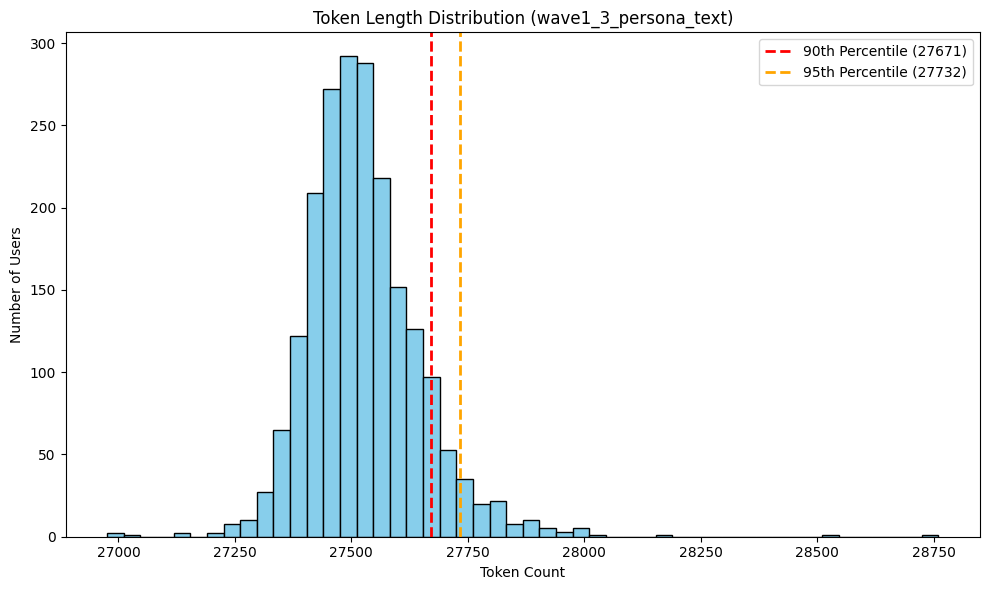

In [75]:
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

# Assuming your DataFrame is already loaded into 'wave_df'
# wave_df = pd.read_csv("your_data.csv") 

print("Loading Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-0.6B", trust_remote_code=True)

print("Tokenizing 'wave1_3_persona_json' and calculating lengths")
# Calculate the token length for every row and store it in a new column
wave_df['token_length'] = wave_df['wave1_3_persona_text'].astype(str).apply(
    lambda x: len(tokenizer.encode(x))
)

# Compute Statistics using native Pandas methods
avg_length = wave_df['token_length'].mean()
p90 = wave_df['token_length'].quantile(0.90)
p95 = wave_df['token_length'].quantile(0.95)
max_length = wave_df['token_length'].max()

print("\n" + "="*40)
print(" TOKEN STATISTICS (Qwen3-0.6B)")
print("="*40)
print(f"Average length: {avg_length:.0f} tokens")
print(f"90% of personas fit within: {p90:.0f} tokens")
print(f"95% of personas fit within: {p95:.0f} tokens")
print(f"Maximum length: {max_length:.0f} tokens")
print("="*40)

# Plot the Distribution
plt.figure(figsize=(10, 6))
plt.hist(wave_df['token_length'], bins=50, color='skyblue', edgecolor='black')
plt.axvline(p90, color='red', linestyle='dashed', linewidth=2, label=f'90th Percentile ({p90:.0f})')
plt.axvline(p95, color='orange', linestyle='dashed', linewidth=2, label=f'95th Percentile ({p95:.0f})')
plt.title('Token Length Distribution (wave1_3_persona_text)')
plt.xlabel('Token Count')
plt.ylabel('Number of Users')
plt.legend()
plt.tight_layout()
plt.show()

Loading Tokenizer...
Tokenizing 'wave1_3_persona_json' and calculating lengths 

 TOKEN STATISTICS (Qwen3-0.6B)
Average length: 35077 tokens
90% of personas fit within: 35245 tokens
95% of personas fit within: 35311 tokens
Maximum length: 36340 tokens


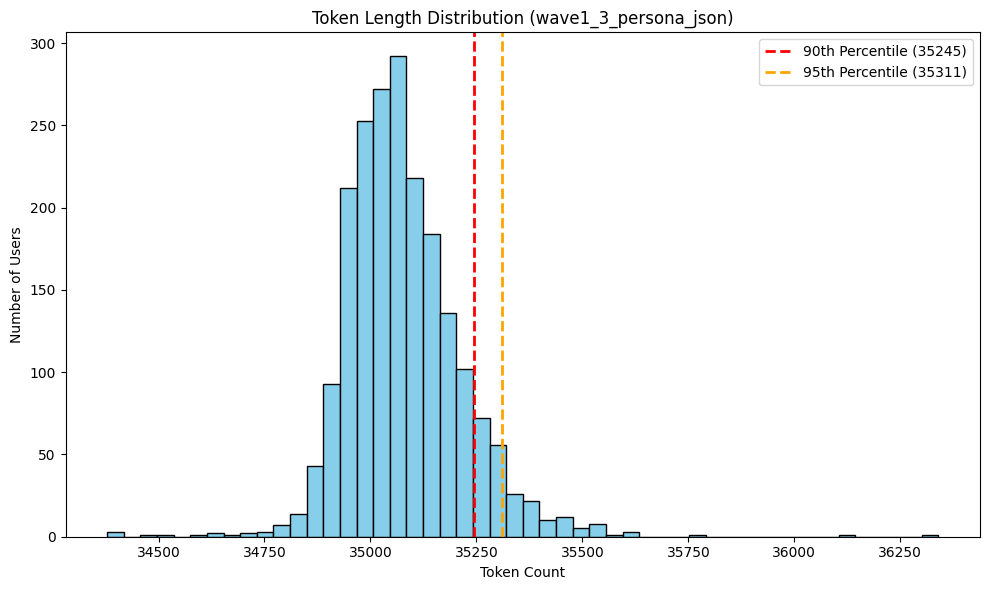

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

# Assuming your DataFrame is already loaded into 'wave_df'
# wave_df = pd.read_csv("your_data.csv") 

print("Loading Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-0.6B", trust_remote_code=True)

print("Tokenizing 'wave1_3_persona_json' and calculating lengths ")
# Calculate the token length for every row and store it in a new column
wave_df['wave1_3_persona_json_token_length'] = wave_df['wave1_3_persona_json'].astype(str).apply(
    lambda x: len(tokenizer.encode(x))
)

# Compute Statistics using native Pandas methods
avg_length = wave_df['wave1_3_persona_json_token_length'].mean()
p90 = wave_df['wave1_3_persona_json_token_length'].quantile(0.90)
p95 = wave_df['wave1_3_persona_json_token_length'].quantile(0.95)
max_length = wave_df['wave1_3_persona_json_token_length'].max()

print("\n" + "="*40)
print(" TOKEN STATISTICS (Qwen3-0.6B)")
print("="*40)
print(f"Average length: {avg_length:.0f} tokens")
print(f"90% of personas fit within: {p90:.0f} tokens")
print(f"95% of personas fit within: {p95:.0f} tokens")
print(f"Maximum length: {max_length:.0f} tokens")
print("="*40)

# Plot the Distribution
plt.figure(figsize=(10, 6))
plt.hist(wave_df['wave1_3_persona_json_token_length'], bins=50, color='skyblue', edgecolor='black')
plt.axvline(p90, color='red', linestyle='dashed', linewidth=2, label=f'90th Percentile ({p90:.0f})')
plt.axvline(p95, color='orange', linestyle='dashed', linewidth=2, label=f'95th Percentile ({p95:.0f})')
plt.title('Token Length Distribution (wave1_3_persona_json)')
plt.xlabel('Token Count')
plt.ylabel('Number of Users')
plt.legend()
plt.tight_layout()
plt.show()

In [77]:

#wave_df.head(1)
wave_df.columns

Index(['pid', 'wave1_3_persona_text', 'wave1_3_persona_json',
       'wave4_Q_wave1_3_A', 'wave4_Q_wave4_A', 'wave1_3_persona_text_wordlen',
       'wave1_3_persona_json_wordlen', 'wave4_Q_wave1_3_A_wordlen',
       'wave4_Q_wave4_A_wordlen', 'token_length',
       'wave1_3_persona_json_token_length'],
      dtype='object')

### Unrolling Person level dataset to Q&A-Person Level

In [78]:
def parse_json_safely(val):
    if isinstance(val, str):
        try:
            return json.loads(val)
        except json.JSONDecodeError:
            return []
    return val if isinstance(val, list) else []

wave_df['wave1_3_persona_json'] = wave_df['wave1_3_persona_json'].apply(parse_json_safely)

In [79]:
wave_df['wave1_3_persona_json'].sample(1)

314    [{'ElementType': 'Block', 'BlockName': 'Demographics', 'BlockType': 'Standard', 'Questions': [{'QuestionID': 'QID11', 'QuestionText': 'Which part of the United States do you currently live in?', 'QuestionType': 'MC', 'Options': ['Northeast (PA, NY, NJ, RI, CT, MA, VT, NH, ME)', 'Midwest (ND, SD, NE, KS, MN, IA, MO, WI, IL, MI, IN, OH)', 'South (TX, OK, AR, LA, KY, TN, MS, AL, WV, DC, MD, DE, VA, NC, SC, GA, FL)', 'West (WA, OR, ID, MT, WY, CA, NV, UT, CO, AZ, NM)', 'Pacific (HI, AK)'], 'Settings': {'Selector': 'SAVR', 'SubSelector': 'TX', 'ForceResponse': 'ON'}, 'Answers': {'SelectedByPosition': 2, 'SelectedText': 'Midwest (ND, SD, NE, KS, MN, IA, MO, WI, IL, MI, IN, OH)'}}, {'QuestionID': 'QID12', 'QuestionText': 'What is the sex that you were assigned at birth?', 'QuestionType': 'MC', 'Options': ['Male', 'Female'], 'Settings': {'Selector': 'SAVR', 'SubSelector': 'TX', 'ForceResponse': 'ON'}, 'Answers': {'SelectedByPosition': 1, 'SelectedText': 'Male'}}, {'QuestionID': 'QID13',

In [80]:
wave_df['wave1_3_persona_text'].sample(1)

1728    Which part of the United States do you currently live in?\nQuestion Type: Single Choice\nOptions:\n  1 - Northeast (PA, NY, NJ, RI, CT, MA, VT, NH, ME)\n  2 - Midwest (ND, SD, NE, KS, MN, IA, MO, WI, IL, MI, IN, OH)\n  3 - South (TX, OK, AR, LA, KY, TN, MS, AL, WV, DC, MD, DE, VA, NC, SC, GA, FL)\n  4 - West (WA, OR, ID, MT, WY, CA, NV, UT, CO, AZ, NM)\n  5 - Pacific (HI, AK)\nAnswer: 1 - Northeast (PA, NY, NJ, RI, CT, MA, VT, NH, ME)\n\nWhat is the sex that you were assigned at birth?\nQuestion Type: Single Choice\nOptions:\n  1 - Male\n  2 - Female\nAnswer: 2 - Female\n\nHow old are you?\nQuestion Type: Single Choice\nOptions:\n  1 - 18-29\n  2 - 30-49\n  3 - 50-64\n  4 - 65+\nAnswer: 2 - 30-49\n\nWhat is the highest level of schooling or degree that you have completed?\nQuestion Type: Single Choice\nOptions:\n  1 - Less than high school\n  2 - High school graduate\n  3 - Some college, no degree\n  4 - Associate's degree\n  5 - College graduate/some postgrad\n  6 - Postgradua

In [81]:
# Step 2: Create a function to flatten the nested structure
def flatten_blocks(row_id, blocks_list):
    records = []
    for block in blocks_list:
        block_name = block.get("BlockName")
        
        # Iterate through the list of questions inside each block
        for q in block.get("Questions", []):
            
            # Safely extract the selected answer text (handles missing answers)
            answers = q.get("Answers", {})
            selected_text = answers.get("SelectedText", None) if isinstance(answers, dict) else None
            
            records.append({
                "participant_id": row_id,
                "block_name": block_name,
                "question_id": q.get("QuestionID"),
                "question_type": q.get("QuestionType"),
                "question_text": q.get("QuestionText"),
                "options": q.get("Options"),
                "selected_answer": selected_text
            })
            
    return records

# Step 3: Apply the function across all rows and combine into a single DataFrame
all_records = []
for index, row in wave_df.iterrows():
    # Pass the DataFrame index (or a specific user ID column) to track participants
    all_records.extend(flatten_blocks(row['pid'], row['wave1_3_persona_json']))

# The final, flattened DataFrame ready for analysis
wave1_3_qa_df = pd.DataFrame(all_records)
print(wave1_3_qa_df.head(1))

   participant_id    block_name question_id question_type  \
0             574  Demographics       QID11            MC   

                                               question_text  \
0  Which part of the United States do you currently live in?   

                                                                                                                                                                                                                                                       options  \
0  [Northeast (PA, NY, NJ, RI, CT, MA, VT, NH, ME), Midwest (ND, SD, NE, KS, MN, IA, MO, WI, IL, MI, IN, OH), South (TX, OK, AR, LA, KY, TN, MS, AL, WV, DC, MD, DE, VA, NC, SC, GA, FL), West (WA, OR, ID, MT, WY, CA, NV, UT, CO, AZ, NM), Pacific (HI, AK)]   

                                                              selected_answer  
0  South (TX, OK, AR, LA, KY, TN, MS, AL, WV, DC, MD, DE, VA, NC, SC, GA, FL)  


In [82]:
wave1_3_qa_df.columns

Index(['participant_id', 'block_name', 'question_id', 'question_type',
       'question_text', 'options', 'selected_answer'],
      dtype='object')

In [83]:
wave1_3_qa_df.shape

(353929, 7)

##### Check None Answers 

In [84]:
wave1_3_qa_df["selected_answer"].apply(
    lambda x: x.count(None) if isinstance(x, list) else 0
).sum()

0

In [85]:
wave1_3_qa_df["options"].apply(
    lambda x: x.count(None) if isinstance(x, list) else 0
).sum()

0

#### Check duplicate Q&A rows 

In [86]:
df_copy = wave1_3_qa_df.copy()

for col in ["options", "selected_answer"]:
    df_copy[col] = df_copy[col].apply(
        lambda x: tuple(x) if isinstance(x, list) else x
    )

print(df_copy.duplicated().sum())

0


In [87]:
wave1_3_qa_df['participant_id'].value_counts().mean()

171.97716229348882

In [88]:
wave1_3_qa_df['question_type'].unique()

array(['MC', 'DB', 'Matrix', 'TE'], dtype=object)

In [89]:
wave1_3_qa_df[wave1_3_qa_df["question_type"] == 'DB'].sample(3)

,participant_id,block_name,question_id,question_type,question_text,options,selected_answer
320360,785,Personality,QID127,DB,"This page contains groups of statements. After reading each group of statements carefully, choose the one statement which best describes the way you have been feeling in the past week, including today . If several statements within a group seem to apply equally well, select each one. Be sure to read all the statements in each group before making your choice .",None,None
14480,244,Cognitive tests,QID62,DB,"Each of the 10 questions in the next task consists of a word in capital letters, followed by five words as the answer options. Please select the word that is most nearly the SAME in meaning as the word in capital letters (the synonym ). Some of the questions may be challenging. Please complete them to the best of your ability. If you have no idea, please take your best guess. Click &ldquo;Next&rdquo; to go on to the first question.",None,None
154673,525,Cognitive tests,QID265,DB,This completes this section. You will now move on to the next section.,None,None


In [90]:
#wave1_3_qa_df[wave1_3_qa_df['participant_id']==1].head(50)
wave1_3_qa_df[
    #(wave1_3_qa_df["question_type"] == 'DB') &
    wave1_3_qa_df["block_name"] == "Economic preferences - intro "].sample(3) 

,participant_id,block_name,question_id,question_type,question_text,options,selected_answer
225870,101,Economic preferences - intro,QID266,DB,"In this final section, you will be asked various questions about your opinions and preferences. In order to help you pace yourself, the ""next"" button will appear only after a few seconds in each question.",None,None
329791,1118,Economic preferences - intro,QID242,DB,"In this section, you will be asked various questions about your opinions and preferences. In order to help you pace yourself, the ""next"" button will appear only after a few seconds in each question.",None,None
20021,1742,Economic preferences - intro,QID266,DB,"In this final section, you will be asked various questions about your opinions and preferences. In order to help you pace yourself, the ""next"" button will appear only after a few seconds in each question.",None,None


In [91]:
question_types = (
    wave1_3_qa_df.groupby('block_name').agg(
        unique_question_counts=("question_id", "nunique"),
        question_types=("question_type", lambda x: sorted(x.unique())))
    .reset_index()
    .sort_values(by='unique_question_counts',ascending=False))

print(question_types)

print(f"Total Q Counts {question_types['unique_question_counts'].sum()}")

                      block_name  unique_question_counts        question_types
0               Cognitive tests                       69          [DB, MC, TE]
5                   Personality                       49  [DB, MC, Matrix, TE]
2          Economic preferences                       36  [DB, MC, Matrix, TE]
1                   Demographics                      14                  [MC]
3  Economic preferences - intro                        2                  [DB]
4                   Forward Flow                       1                  [TE]
Total Q Counts 171


In [92]:
question_type_summary = (
    wave1_3_qa_df
    .groupby("question_type", as_index=False)
    .size()
    .rename(columns={"size": "num_rows"})
)

question_type_summary["percentage"] = (
    question_type_summary["num_rows"]
    / len(wave1_3_qa_df)
    * 100
).round(2)

question_type_summary = question_type_summary.sort_values(
    "num_rows", ascending=False
)

print(question_type_summary)

  question_type  num_rows  percentage
1            MC    220199       62.22
2        Matrix     59682       16.86
3            TE     45236       12.78
0            DB     28812        8.14


##### Q & A Analysis - Wave 4 

##### Part A - Wave 4 and Wave 1_3 overlapping Questions

In [93]:
wave_df['wave4_Q_wave1_3_A'] = wave_df['wave4_Q_wave1_3_A'].apply(parse_json_safely) 


# Step 3: Apply the function across all rows and combine into a single DataFrame
all_records = []
for index, row in wave_df.iterrows():
    # Pass the DataFrame index (or a specific user ID column) to track participants
    all_records.extend(flatten_blocks(row['pid'], row['wave4_Q_wave1_3_A']))

# The final, flattened DataFrame ready for analysis
wave4_13_qa_df = pd.DataFrame(all_records)
wave4_13_qa_df.head(1)


,participant_id,block_name,question_id,question_type,question_text,options,selected_answer
0,574,False consensus,QID287,Matrix,Would you support or oppose...,None,"[Strongly oppose, Somewhat oppose, Somewhat oppose, Strongly oppose, Somewhat support, Somewhat support, Somewhat support, Somewhat oppose, Somewhat support, Somewhat support]"


In [94]:


question_types = (
    wave4_13_qa_df.groupby('block_name').agg(
        unique_question_counts=("question_id", "nunique"),
        question_types=("question_type", lambda x: sorted(x.unique())))
    .reset_index()
    .sort_values(by='unique_question_counts',ascending=False))

print(f"Total Q Counts Wave 4 dataset {question_types['unique_question_counts'].sum()}")
print(question_types)
question_types.to_csv("Wave4_BlockTypeQuestionStats.csv",index=None)




Total Q Counts Wave 4 dataset 85
                                         block_name  unique_question_counts  \
25                    Product Preferences - Pricing                      41   
20          Non-experimental heuristics and biases                        5   
4                Anchoring - African countries high                       2   
5                Anchoring - African countries low                        2   
6                          Anchoring - redwood high                       2   
7                           Anchoring - redwood low                       2   
28                          Proportion dominance 1C                       1   
22                          Outcome bias - success                        1   
23  Probability matching vs. maximizing - Problem 1                       1   
24  Probability matching vs. maximizing - Problem 2                       1   
26                         Proportion dominance 1A                        1   
27                 

In [95]:
#wave_df.sample(1)

In [96]:
wave4_13_qa_df.shape

(131712, 7)

In [97]:
wave_df.columns

Index(['pid', 'wave1_3_persona_text', 'wave1_3_persona_json',
       'wave4_Q_wave1_3_A', 'wave4_Q_wave4_A', 'wave1_3_persona_text_wordlen',
       'wave1_3_persona_json_wordlen', 'wave4_Q_wave1_3_A_wordlen',
       'wave4_Q_wave4_A_wordlen', 'token_length',
       'wave1_3_persona_json_token_length'],
      dtype='object')

In [98]:
# question_types = (
#     wave4_13_qa_df.groupby('block_name')['question_type']
#     .nunique()
#     .reset_index(name='unique_question_type')
#     .sort_values(by='unique_question_type',ascending=False))
# print(question_types)

#rint(f"Total Q Counts {question_types['unique_question_type'].sum()}")

In [99]:
wave_df['wave4_Q_wave4_A'] = wave_df['wave4_Q_wave4_A'].apply(parse_json_safely) 


# Step 3: Apply the function across all rows and combine into a single DataFrame
all_records = []
for index, row in wave_df.iterrows():
    # Pass the DataFrame index (or a specific user ID column) to track participants
    all_records.extend(flatten_blocks(row['pid'], row['wave4_Q_wave4_A']))

all_records

[{'participant_id': 574,
  'block_name': 'False consensus ',
  'question_id': 'QID287',
  'question_type': 'Matrix',
  'question_text': 'Would you support or oppose...',
  'options': None,
  'selected_answer': ['Somewhat oppose',
   'Somewhat support',
   'Neither oppose nor support',
   'Strongly oppose',
   'Somewhat support',
   'Somewhat support',
   'Somewhat support',
   'Somewhat oppose',
   'Somewhat support',
   'Neither oppose nor support']},
 {'participant_id': 574,
  'block_name': 'Base-rate 70 engineers',
  'question_id': 'QID156',
  'question_type': 'Slider',
  'question_text': 'A panel of psychologist have interviewed and administered personality tests to 70 engineers and 30 lawyers, all successful in their respective fields. On the basis of this information, thumbnail descriptions of the 70 engineers and 30 lawyers have been written. Below is one description, chosen at random from the 100 available descriptions. Jack is a 45-year-old man. He is married and has four chil

In [100]:


# The final, flattened DataFrame ready for analysis
wave4_4_qa_df = pd.DataFrame(all_records)
print(wave4_4_qa_df.shape)


question_types = (
    wave4_4_qa_df.groupby('block_name').agg(
        unique_question_counts=("question_id", "nunique"),
        question_types=("question_type", lambda x: sorted(x.unique())))
    .reset_index()
    .sort_values(by='unique_question_counts',ascending=False))
#question_types
#print(f"Total Question Counts for Wave 4 dataset (No overlap): {question_types['unique_question_counts'].sum()}")



(131712, 7)


In [101]:
wave4_13_qa_df.head(3)

,participant_id,block_name,question_id,question_type,question_text,options,selected_answer
0,574,False consensus,QID287,Matrix,Would you support or oppose...,None,"[Strongly oppose, Somewhat oppose, Somewhat oppose, Strongly oppose, Somewhat support, Somewhat support, Somewhat support, Somewhat oppose, Somewhat support, Somewhat support]"
1,574,Base-rate 70 engineers,QID156,Slider,"A panel of psychologist have interviewed and administered personality tests to 70 engineers and 30 lawyers, all successful in their respective fields. On the basis of this information, thumbnail descriptions of the 70 engineers and 30 lawyers have been written. Below is one description, chosen at random from the 100 available descriptions. Jack is a 45-year-old man. He is married and has four children. He is generally conservative, careful, and ambitious. He shows no interest in political and social issues and spends most of his free time on his many hobbies which include home carpentry, sailing, and mathematical puzzles. The probability that Jack is one of the 70 engineers in the sample of 100 is ___%. Please indicate the probability on a scale from 0 to 100.",None,None
2,574,Disease-loss,QID158,MC,"Imagine that the U.S. is preparing for the outbreak of an unusual disease, which is expected to kill 600 people. Two alternative programs to combat the disease have been proposed. Assume that the exact scientific estimate of the consequences of the programs are as follows: If Program A is adopted, 400 people will die. If Program B is adopted, there is 1/3 probability that nobody people will die, and 2/3 probability that 600 people be die. Which of the two programs would you favor?","[I strongly favor program A, I favor program A, I slightly favor program A, I slightly favor program B, I favor program B, I strongly favor program B]",I slightly favor program A


In [102]:
wave4_4_qa_df.head(3)

,participant_id,block_name,question_id,question_type,question_text,options,selected_answer
0,574,False consensus,QID287,Matrix,Would you support or oppose...,None,"[Somewhat oppose, Somewhat support, Neither oppose nor support, Strongly oppose, Somewhat support, Somewhat support, Somewhat support, Somewhat oppose, Somewhat support, Neither oppose nor support]"
1,574,Base-rate 70 engineers,QID156,Slider,"A panel of psychologist have interviewed and administered personality tests to 70 engineers and 30 lawyers, all successful in their respective fields. On the basis of this information, thumbnail descriptions of the 70 engineers and 30 lawyers have been written. Below is one description, chosen at random from the 100 available descriptions. Jack is a 45-year-old man. He is married and has four children. He is generally conservative, careful, and ambitious. He shows no interest in political and social issues and spends most of his free time on his many hobbies which include home carpentry, sailing, and mathematical puzzles. The probability that Jack is one of the 70 engineers in the sample of 100 is ___%. Please indicate the probability on a scale from 0 to 100.",None,None
2,574,Disease-loss,QID158,MC,"Imagine that the U.S. is preparing for the outbreak of an unusual disease, which is expected to kill 600 people. Two alternative programs to combat the disease have been proposed. Assume that the exact scientific estimate of the consequences of the programs are as follows: If Program A is adopted, 400 people will die. If Program B is adopted, there is 1/3 probability that nobody people will die, and 2/3 probability that 600 people be die. Which of the two programs would you favor?","[I strongly favor program A, I favor program A, I slightly favor program A, I slightly favor program B, I favor program B, I strongly favor program B]",I slightly favor program B


### Answers Evaluation - Test/Retest 

##### 1. Clean Up - Remove DB Questions 

In [103]:
wave1_3_qa_df[wave1_3_qa_df['question_type']=='DB']['selected_answer'].value_counts()

Series([], Name: count, dtype: int64)

In [104]:
wave4_13_qa_df_cleaned = wave4_13_qa_df[~(wave4_13_qa_df['question_type']=='DB')]
wave4_4_qa_df_cleaned = wave4_4_qa_df[~(wave4_4_qa_df['question_type']=='DB')]
print(wave4_13_qa_df.shape,wave4_4_qa_df.shape)
print(wave4_13_qa_df_cleaned.shape,wave4_4_qa_df_cleaned.shape)
print(wave4_13_qa_df.shape[0]-wave4_13_qa_df_cleaned.shape[0])

(131712, 7) (131712, 7)
(129654, 7) (129654, 7)
2058


##### 2. Remove Empty responses in both waves


In [116]:

# 1. Merge the datasets to align past and current answers
eval_df = pd.merge(
    wave4_13_qa_df_cleaned[['participant_id', 'question_id', 'question_type', 'selected_answer']],
    wave4_4_qa_df_cleaned[['participant_id', 'question_id', 'selected_answer']],
    on=['participant_id', 'question_id'],
    suffixes=('_wave13', '_wave4')
)


In [117]:

# 1. Replace empty strings or pure whitespace with true NaN
eval_df['selected_answer_wave13'] = eval_df['selected_answer_wave13'].replace(r'^\s*$', np.nan, regex=True)
eval_df['selected_answer_wave4'] = eval_df['selected_answer_wave4'].replace(r'^\s*$', np.nan, regex=True)
# Drop any rows where a human skipped the question in either wave
original_len = len(eval_df)
print(original_len)


# 2. Now count the true missing values
total_skips = eval_df[['selected_answer_wave13', 'selected_answer_wave4']].isna().any(axis=1).sum()
print(f"Total skipped questions (NaN or empty): {total_skips}")

print(eval_df[
    eval_df["selected_answer_wave13"].isna() &
    eval_df["selected_answer_wave4"].isna()
].shape)


mask = eval_df[['selected_answer_wave13', 'selected_answer_wave4']].isna().any(axis=1)

print(mask.shape)
# View all skipped rows
print(eval_df[mask].sample(10))
print(eval_df[mask]['question_type'].value_counts())

# 3. Finally, execute the drop safely
eval_df = eval_df.dropna(subset=['selected_answer_wave13', 'selected_answer_wave4'])
print(eval_df.shape)

129654
Total skipped questions (NaN or empty): 10290
(10290, 5)
(129654,)
        participant_id question_id question_type selected_answer_wave13  \
44553             1370      QID181            TE                   None   
96083              728      QID170            TE                   None   
85314             1702      QID181            TE                   None   
30829             2057      QID290        Slider                   None   
79008             1887      QID164            TE                   None   
112776            1182      QID164            TE                   None   
106303            1933      QID290        Slider                   None   
89277             1037      QID164            TE                   None   
107994             532      QID181            TE                   None   
79129             1207      QID154        Slider                   None   

       selected_answer_wave4  
44553                   None  
96083                   None  
85314  

In [ ]:
eval_df['question_type'].value_counts()

question_type
MC        109074
Matrix     10290
Name: count, dtype: int64

#####  Multiple Choice Question Evaluation - Exact Match

In [ ]:
wave4_13_qa_df[wave4_13_qa_df["question_type"] == 'MC'].sample(3)

,participant_id,block_name,question_id,question_type,question_text,options,selected_answer
100426,255,Proportion dominance 1A,QID174,MC,"Imagine that highway safety experts have determined that a substantial number of people are at risk of dying in a type of automobile fire. A requirement that every car have a built-in fire extinguisher (estimated cost, $300) would save the 150 people who would otherwise die every year in this type of automobile fire. Rate the following statement about yourself: I would be supportive of this requirement.","[Disagree strongly, Disagree a little, Neither agree nor disagree, Agree a little, Agree strongly]",Agree strongly
77475,753,Product Preferences - Pricing,QID9_12,MC,"Please consider the following product category: Dairy - Milk - Refrigerated. Suppose you are in a grocery store, and you see the following product in that category: Great Value Milk Whole Vitamin D Gallon. The product is priced at: $5.49. Would you or would you not purchase this product?","[Yes, I would purchase the product, No, I would not purchase the product]","No, I would not purchase the product"
42150,1820,Product Preferences - Pricing,QID9_15,MC,"Please consider the following product category: Cat Food - Wet Type. Suppose you are in a grocery store, and you see the following product in that category: Purina Fancy Feast Chicken Feast Classic Grain Free Wet Cat Food Pate - 3 oz. Can. The product is priced at: $0.18. Would you or would you not purchase this product?","[Yes, I would purchase the product, No, I would not purchase the product]","Yes, I would purchase the product"


In [ ]:
# Isolate Multiple Choice questions
mc_df = eval_df[eval_df['question_type'] == 'MC'].copy()
print(mc_df.shape)
# Calculate Exact Match
mc_df['is_match'] = mc_df['selected_answer_wave13'] == mc_df['selected_answer_wave4']
print(mc_df['is_match'].value_counts())

mc_reliability = mc_df['is_match'].mean()

print(f"Categorical (MC) Exact Match Ceiling: {mc_reliability:.2%}")


(109074, 5)
is_match
True     85156
False    23918
Name: count, dtype: int64
Categorical (MC) Exact Match Ceiling: 78.07%


##### Matrix Type Question Evaluation

In [ ]:
wave4_13_qa_df[wave4_13_qa_df["question_type"] == 'Matrix'].sample(3)

,participant_id,block_name,question_id,question_type,question_text,options,selected_answer
106257,1430,Probability matching vs. maximizing - Problem 1,QID198,Matrix,"Consider the following hypothetical situation: A deck with 10 cards is randomly shuffled 10 separate times. The 10 cards are composed of 7 cards with the number “1” on the down side and 3 cards with the number “2” on the down side. Each time the 10 cards are reshuffled, your task is to predict the number on the down side of the top card. Imagine that you will receive $100 for each downside number you correctly predict, and that you want to earn as much money as possible. What would you predict after ...",None,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
43651,325,Linda -no conjunction,QID159,Matrix,"Linda is 31 years old, single, outspoken, and very bright. She majored in philosophy. As a student, she was deeply concerned with issues of discrimination and social justice, and also participated in anti-nuclear demonstrations. Please complete the statements below.",None,"[Very probable, Very improbable, Very improbable]"
18385,1496,Probability matching vs. maximizing - Problem 2,QID203,Matrix,Consider the following situation: A die with 4 red faces and 2 green faces will be rolled 6 times. Before each roll you will be asked to predict which color (red or green) will show up once the die is rolled. Which color is most likely to show up after ...,None,"[red, red, green, red, green, red]"


##### Create Eval dataset

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import ast

def clean_matrix_cell(val):
    """Safely converts string representations of lists into actual lists."""
    if isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except (ValueError, SyntaxError):
            return [val]
    elif isinstance(val, list):
        return val
    return []

# 1. Clean and prepare lists (keeping them unexploded)
m_wave13 = wave4_13_qa_df[wave4_13_qa_df['question_type'] == 'Matrix'].copy()
m_wave4 = wave4_4_qa_df[wave4_4_qa_df['question_type'] == 'Matrix'].copy()

m_wave13['selected_answer'] = m_wave13['selected_answer'].apply(clean_matrix_cell)
m_wave4['selected_answer'] = m_wave4['selected_answer'].apply(clean_matrix_cell)

# 2. Merge directly on participant and question ID
matrix_eval = pd.merge(
    m_wave13[['participant_id', 'question_id','block_name','selected_answer']],
    m_wave4[['participant_id', 'question_id','block_name', 'selected_answer']],
    on=['participant_id', 'question_id','block_name'],
    suffixes=('_wave13', '_wave4')
)
print(matrix_eval.shape)

(10290, 5)


In [ ]:
matrix_eval['question_id'].unique()

array(['QID287', 'QID160', 'QID198', 'QID288', 'QID289', 'QID159',
       'QID203'], dtype=object)

In [ ]:
matrix_eval.head(3)

,participant_id,question_id,block_name,selected_answer_wave13,selected_answer_wave4
0,574,QID287,False consensus,"[Strongly oppose, Somewhat oppose, Somewhat oppose, Strongly oppose, Somewhat support, Somewhat support, Somewhat support, Somewhat oppose, Somewhat support, Somewhat support]","[Somewhat oppose, Somewhat support, Neither oppose nor support, Strongly oppose, Somewhat support, Somewhat support, Somewhat support, Somewhat oppose, Somewhat support, Neither oppose nor support]"
1,574,QID160,Linda-conjunction,"[Very probable, Extremely probable, Extremely probable]","[Moderately probable, Extremely probable, Moderately probable]"
2,574,QID198,Probability matching vs. maximizing - Problem 1,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"


##### Question Id to possible Answer ranges mapping

In [ ]:

# Load the catalog
with open('/Users/rahulmehta/Desktop/Job2026/Companies/AmitySolutions/datasets/question_catalog/question_catalog.json', 'r') as f:
    catalog = json.load(f)

# Dictionaries to store our dynamic rules
likert_maps = {}
scale_ranges = {}

for question in catalog:
    if question.get('QuestionType') == 'Matrix' and 'Columns' in question:
        qid = question['QuestionID']
        columns = question['Columns']
        
        # 1. Calculate the range (Number of options - 1)
        # e.g., 5 options = range of 4. 9 options = range of 8.
        scale_ranges[qid] = len(columns) - 1
        
        # 2. Build the text-to-integer mapping for this specific question
        q_map = {}
        for idx, col_text in enumerate(columns):
            # Clean text (lowercase, strip whitespace) to ensure robust matching
            clean_text = str(col_text).strip().lower()
            q_map[clean_text] = idx + 1  # 1-indexed (1, 2, 3...)
            
        likert_maps[qid] = q_map

print(f"Loaded mappings for {len(likert_maps)} matrix questions.")
print(f"Example range for QID29: {scale_ranges.get('QID29')}") # Should output 8
print(f'Scales for QID29')
likert_maps['QID29']

Loaded mappings for 36 matrix questions.
Example range for QID29: 8
Scales for QID29


{'not important to me 1': 1,
 '2': 2,
 '3': 3,
 '4': 4,
 'quite important to me 5': 5,
 '6': 6,
 '7': 7,
 '8': 8,
 'highly important to me 9': 9}

In [ ]:
likert_maps.keys()

dict_keys(['QID25', 'QID26', 'QID29', 'QID35', 'QID232', 'QID235', 'QID27', 'QID30', 'QID125', 'QID233', 'QID84', 'QID244', 'QID245', 'QID246', 'QID247', 'QID248', 'QID250', 'QID251', 'QID252', 'QID276', 'QID277', 'QID278', 'QID279', 'QID28', 'QID234', 'QID236', 'QID237', 'QID238', 'QID239', 'QID287', 'QID160', 'QID203', 'QID288', 'QID289', 'QID198', 'QID159'])

In [ ]:
likert_maps.values()

dict_values([{'disagree strongly': 1, 'disagree a little': 2, 'neither agree nor disagree': 3, 'agree a little': 4, 'agree strongly': 5}, {'disagree strongly': 1, 'disagree a little': 2, 'neither agree nor disagree': 3, 'agree a little': 4, 'agree strongly': 5}, {'not important to me 1': 1, '2': 2, '3': 3, '4': 4, 'quite important to me 5': 5, '6': 6, '7': 7, '8': 8, 'highly important to me 9': 9}, {'disagree strongly': 1, 'disagree a little': 2, 'neither agree nor disagree': 3, 'agree a little': 4, 'agree strongly': 5}, {'disagree strongly': 1, 'disagree a little': 2, 'neither agree nor disagree': 3, 'agree a little': 4, 'agree strongly': 5}, {'disagree strongly': 1, 'disagree a little': 2, 'neither agree nor disagree': 3, 'agree a little': 4, 'agree strongly': 5}, {'false': 1, 'true': 2}, {'extremely inaccurate 1': 1, '2': 2, '3': 3, '4': 4, 'neither inaccurate nor accurate 5': 5, '6': 6, '7': 7, '8': 8, 'extremely accurate 9': 9}, {'not at all 0': 1, '1': 2, '2': 3, 'severely - i ba

In [ ]:
with open("../datasets/results/evals/matrixQ_likert.pkl", "wb") as file:
    pickle.dump(likert_maps, file)

In [ ]:
# Open the file in read-binary mode ('rb')
with open('../datasets/results/evals/matrixQ_likert.pkl', 'rb') as file:
    # Load the data from the file
    loaded_pkl = pickle.load(file)
loaded_pkl.keys()

dict_keys(['QID25', 'QID26', 'QID29', 'QID35', 'QID232', 'QID235', 'QID27', 'QID30', 'QID125', 'QID233', 'QID84', 'QID244', 'QID245', 'QID246', 'QID247', 'QID248', 'QID250', 'QID251', 'QID252', 'QID276', 'QID277', 'QID278', 'QID279', 'QID28', 'QID234', 'QID236', 'QID237', 'QID238', 'QID239', 'QID287', 'QID160', 'QID203', 'QID288', 'QID289', 'QID198', 'QID159'])

### Create MC Questions Text to Int Mapping file

In [ ]:

# Dictionaries to store our dynamic rules
likert_maps_mc = {}
scale_ranges_mc = {}

for question in catalog:
    if question.get('QuestionType') == 'MC' and 'Options' in question:
        qid = question['QuestionID']
        columns = question['Options']
        
        # 1. Calculate the range (Number of options - 1)
        # e.g., 5 options = range of 4. 9 options = range of 8.
        scale_ranges_mc[qid] = len(columns) - 1
        
        # 2. Build the text-to-integer mapping for this specific question
        q_map = {}
        for idx, col_text in enumerate(columns):
            # Clean text (lowercase, strip whitespace) to ensure robust matching
            clean_text = str(col_text).strip().lower()
            q_map[clean_text] = idx + 1  # 1-indexed (1, 2, 3...)
            
        likert_maps_mc[qid] = q_map

print(f"Loaded mappings for {len(likert_maps_mc)} MC questions.")
print(f"Example range for QID126: {scale_ranges_mc.get('QID126')}") # Should output 8
print(f'Scales for QID126')
likert_maps_mc['QID126']

Loaded mappings for 175 MC questions.
Example range for QID126: 3
Scales for QID126


{"i don't feel sad": 1,
 'i feel sad': 2,
 "i am sad all the time and i can't snap out of it": 3,
 "i am so sad or unhappy that i can't stand it": 4}

In [ ]:
with open("../datasets/results/evals/MCQ_likert.pkl", "wb") as file:
    pickle.dump(likert_maps_mc, file)

In [ ]:
values = list(scale_ranges.values())

print(f"Count  : {len(values)}")
print(f"Mean   : {statistics.mean(values):.2f}")
print(f"Median : {statistics.median(values)}")
print(f"Min    : {min(values)}")
print(f"Max    : {max(values)}")
print(f"Std    : {statistics.stdev(values):.2f}")  # sample standard deviation

Count  : 36
Mean   : 3.11
Median : 4.0
Min    : 1
Max    : 8
Std    : 2.16


In [ ]:
len(scale_ranges)
# 36 

36

#### Map it to our answer response dataset

In [ ]:
# 3. Define the evaluator function to process the lists internally
def evaluate_matrix_row(row):
    qid = row['question_id']
    list_past = row['selected_answer_wave13']
    list_current = row['selected_answer_wave4']
    
    # Skip if lists are empty or lengths don't match (indicating a survey error)
    if not list_past or not list_current or len(list_past) != len(list_current):
        return np.nan
        
    # Retrieve the dynamic mappings from our loaded catalog dictionaries
    q_map = likert_maps.get(qid, {})
    q_range = scale_ranges.get(qid)
    
    if not q_map or not q_range:
        return np.nan # Skip if we don't have the scale range from the catalog
        
    sub_item_accuracies = []
    
    # Iterate through the paired answers in the lists
    for ans_p, ans_c in zip(list_past, list_current):
        # Clean text
        clean_p = str(ans_p).strip().lower()
        clean_c = str(ans_c).strip().lower()
        
        # Map text to numeric score
        score_p = q_map.get(clean_p)
        score_c = q_map.get(clean_c)
        
        # Fallback for numeric strings (e.g., if the user typed "4")
        if score_p is None:
            try: score_p = float(clean_p)
            except ValueError: pass
        if score_c is None:
            try: score_c = float(clean_c)
            except ValueError: pass
            
        # Calculate Scale-Normalized Accuracy for this specific sub-item
        if score_p is not None and score_c is not None:
            accuracy = 1 - (abs(score_p - score_c) / q_range)
            sub_item_accuracies.append(accuracy)
            
    # Return the mean accuracy across all valid sub-items for this matrix task
    if sub_item_accuracies:
        return sum(sub_item_accuracies) / len(sub_item_accuracies)
    
    return np.nan

# 4. Apply the function to create a task-level accuracy column
matrix_eval['task_normalized_accuracy'] = matrix_eval.apply(evaluate_matrix_row, axis=1)

# Drop rows that couldn't be evaluated (e.g., skips or mapping failures)
matrix_eval_clean = matrix_eval.dropna(subset=['task_normalized_accuracy'])

# 5. Output the final global metrics
print("--- MATRIX QUESTION EVALUATION (UNEXPLODED) ---")
print(f"Total Matrix Blocks Analyzed: {len(matrix_eval_clean)}")
print(f"Global Matrix Normalized Accuracy (Human Ceiling): {matrix_eval_clean['task_normalized_accuracy'].mean():.2%}")

--- MATRIX QUESTION EVALUATION (UNEXPLODED) ---
Total Matrix Blocks Analyzed: 10290
Global Matrix Normalized Accuracy (Human Ceiling): 83.45%


##### Block Level Task normalized accuracy

In [ ]:
# Group by block_name and calculate the metrics
block_level_summary = matrix_eval_clean.groupby('block_name').agg(
    mean_normalized_accuracy=('task_normalized_accuracy', 'mean'),
    unique_questions=('question_id', 'nunique'),
    total_responses=('participant_id', 'count')
).reset_index()

# Calculate the percentage of total responses for each block
total_matrix_responses = block_level_summary['total_responses'].sum()
block_level_summary['pct_of_total_responses'] = block_level_summary['total_responses'] / total_matrix_responses

# Sort the results from highest to lowest accuracy
block_level_summary = block_level_summary.sort_values(by='mean_normalized_accuracy', ascending=False)

print("--- BLOCK-LEVEL NORMALIZED ACCURACY ---")

# Apply percentage formatting to both the accuracy and the new distribution column
formatters = {
    'mean_normalized_accuracy': '{:.2%}'.format,
    'pct_of_total_responses': '{:.2%}'.format
}
print(block_level_summary.to_string(index=False, formatters=formatters))

--- BLOCK-LEVEL NORMALIZED ACCURACY ---
                                     block_name mean_normalized_accuracy  unique_questions  total_responses pct_of_total_responses
                               False consensus                    87.44%                 1             2058                 20.00%
        Non-experimental heuristics and biases                    86.32%                 2             4116                 40.00%
                         Linda -no conjunction                    83.24%                 1             1029                 10.00%
                              Linda-conjunction                   81.57%                 1             1029                 10.00%
Probability matching vs. maximizing - Problem 2                   76.17%                 1             1026                  9.97%
Probability matching vs. maximizing - Problem 1                   73.36%                 1             1032                 10.03%


### Given predictions File of model, get Past answers for the given PID + QID pair

In [ ]:
# Read json predictions
pred_df = pd.read_json('/Users/rahulmehta/Desktop/Job2026/Companies/AmitySolutions/datasets/results/qwen3-0.6b-sft/predictions.jsonl', lines=True)
pred_df.columns = ['participant_id','question_id', 'target_answer', 'predicted_answer']


In [ ]:

# Filter wave 1-3 previous answer for the predictions
pred_df = pd.merge(wave4_13_qa_df,pred_df,how="inner",on=["participant_id","question_id"])
pred_df[pred_df['question_id']=='QID157']

,participant_id,block_name,question_id,question_type,question_text,options,selected_answer,target_answer,predicted_answer
0,377,Disease - gain,QID157,MC,"Imagine that the U.S. is preparing for the outbreak of an unusual disease, which is expected to kill 600 people. Two alternative programs to combat the disease have been proposed. Assume that the exact scientific estimate of the consequences of the programs are as follows: If Program A is adopted, 200 people will be saved. If Program B is adopted, there is 1/3 probability that 600 people will be saved, and 2/3 probability that no people will be saved. Which of the two programs would you favor?","[I strongly favor program A, I favor program A, I slightly favor program A, I slightly favor program B, I favor program B, I strongly favor program B]",I slightly favor program B,I slightly favor program B,I slightly favor program B.


In [ ]:
pred_df['block_name'].unique()

array(['Disease - gain ', 'Outcome bias - failure',
       'Anchoring - African countries high', 'Anchoring - redwood high',
       'Less is More Gamble A ', 'Proportion dominance 1A ',
       'Proportion dominance 2A', 'Absolute vs. relative - jacket',
       'WTA/WTP Thaler problem - WTA certainty', 'Allais Form 2',
       'Myside Ford', 'Non-experimental heuristics and biases ',
       'Product Preferences - Pricing'], dtype=object)

In [ ]:
pred_df.rename(columns={'participant_id':'pid'},inplace=True)
pred_df.to_csv()
file_name = "/Users/rahulmehta/Desktop/Job2026/Companies/AmitySolutions/datasets/results/qwen3-0.6b-sft/hisotrical_answers.jsonl"
pred_df.to_json(file_name, orient='records', lines=True)
